In [ ]:
!pip install np_utils
!pip install spectral


import keras
import tensorflow as tf
from keras.layers import Conv2D, Conv3D, Flatten, Dense, Reshape, BatchNormalization, MaxPooling2D, UpSampling2D
from keras.layers import Dropout, Input, concatenate
from keras.models import Model
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint
import np_utils

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, cohen_kappa_score

from operator import truediv

from plotly.offline import init_notebook_mode

import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import os
import spectral

init_notebook_mode(connected=True)
%matplotlib inline


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for np_utils: filename=np_utils-0.6.0-py3-none-any.whl size=56437 sha256=c590473f02d6d7f56f6e714c2d8f166f8fbc40caa7c2151de7ea30258c6e9d56
  Stored in directory: /root/.cache/pip/wheels/dd/bd/f5/0975fe5179dfa2f996b436596b159824432fb3c1ca74bcf43e
Successfully built np_utils
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 9.5 MB/s eta 0:00:00


In [ ]:
if not (os.path.isfile('Indian_pines_corrected.mat')):
  !wget http://www.ehu.eus/ccwintco/uploads/6/67/Indian_pines_corrected.mat
if not (os.path.isfile('Indian_pines_gt.mat')):
  !wget http://www.ehu.eus/ccwintco/uploads/c/c4/Indian_pines_gt.mat
if not (os.path.isfile('Salinas_corrected.mat')):
  !wget http://www.ehu.eus/ccwintco/uploads/a/a3/Salinas_corrected.mat
if not (os.path.isfile('Salinas_gt.mat')):
  !wget http://www.ehu.eus/ccwintco/uploads/f/fa/Salinas_gt.mat
if not (os.path.isfile('PaviaU.mat')):
  !wget http://www.ehu.eus/ccwintco/uploads/e/ee/PaviaU.mat
if not (os.path.isfile('PaviaU_gt.mat')):
  !wget http://www.ehu.eus/ccwintco/uploads/5/50/PaviaU_gt.mat

--2026-05-01 07:04:42--  http://www.ehu.eus/ccwintco/uploads/6/67/Indian_pines_corrected.mat
Resolving www.ehu.eus (www.ehu.eus)... 158.227.0.65, 2001:720:1410::65
Connecting to www.ehu.eus (www.ehu.eus)|158.227.0.65|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.ehu.eus/ccwintco/uploads/6/67/Indian_pines_corrected.mat [following]
--2026-05-01 07:04:43--  https://www.ehu.eus/ccwintco/uploads/6/67/Indian_pines_corrected.mat
Connecting to www.ehu.eus (www.ehu.eus)|158.227.0.65|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5953527 (5.7M)
Saving to: ‘Indian_pines_corrected.mat’

Indian_pines_correc 100%[===================>]   5.68M   715KB/s    in 7.2s    

2026-05-01 07:04:51 (809 KB/s) - ‘Indian_pines_corrected.mat’ saved [5953527/5953527]

URL transformed to HTTPS due to an HSTS policy
--2026-05-01 07:04:51--  https://www.ehu.eus/ccwintco/uploads/c/c4/Indian_pines_gt.mat
Resolving www.ehu.eus (www.ehu.eu

In [ ]:
dataset = 'IP'
test_ratio = 0.7
windowSize = 25

In [ ]:
def loadData(name):
    data_path = os.path.join(os.getcwd(),'')
    if name == 'IP':
        data = sio.loadmat(os.path.join(data_path, 'Indian_pines_corrected.mat'))['indian_pines_corrected']
        labels = sio.loadmat(os.path.join(data_path, 'Indian_pines_gt.mat'))['indian_pines_gt']
    elif name == 'SA':
        data = sio.loadmat(os.path.join(data_path, 'Salinas_corrected.mat'))['salinas_corrected']
        labels = sio.loadmat(os.path.join(data_path, 'Salinas_gt.mat'))['salinas_gt']
    elif name == 'PU':
        data = sio.loadmat(os.path.join(data_path, 'PaviaU.mat'))['paviaU']
        labels = sio.loadmat(os.path.join(data_path, 'PaviaU_gt.mat'))['paviaU_gt']
    elif name == 'BT':
        data = sio.loadmat(os.path.join(data_path, 'Botswana.mat'))['Botswana']
        labels = sio.loadmat(os.path.join(data_path, 'Botswana_gt.mat'))['Botswana_gt']

    return data, labels


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# REPLACED: splitTrainTestSet() — old random split caused spatial data leakage
#           because 25×25 patches from adjacent pixels share up to 24 rows/cols
#           of overlap. Samples were therefore NOT spatially independent.
#
# NEW: spatially disjoint block-based split operating on pixel coordinates.
#      The image is divided into a grid of non-overlapping blocks; whole blocks
#      are assigned exclusively to train or test so no patch window can straddle
#      both partitions.  The approximate test fraction is preserved via the
#      block-level ratio (test_ratio).
# ─────────────────────────────────────────────────────────────────────────────
# def splitTrainTestSet(X, y, testRatio, randomState=345):
#     """
#     Spatially disjoint block-based train/test split.

#     Parameters
#     ----------
#     X : ndarray, shape (H, W, C)  — PCA-reduced hyperspectral image
#     y : ndarray, shape (H, W)     — ground-truth label map
#     testRatio  : float            — approximate fraction of *labelled* pixels for test
#     randomState: int              — random seed for reproducible block assignment

#     Returns
#     -------
#     train_mask, test_mask : boolean arrays of shape (H, W)
#         True where the pixel belongs to the respective split.
#         Pixels with label 0 (background) are False in both masks.
#     """
#     H, W = y.shape

#     # ── 1. Choose block size so each block is strictly larger than the patch
#     #       window; a block side of 2×windowSize guarantees zero patch overlap
#     #       across block boundaries.
#     block_size = 2 * windowSize          # e.g. 50 for windowSize=25

#     # ── 2. Build a grid of block indices covering the whole image
#     row_starts = np.arange(0, H, block_size)
#     col_starts = np.arange(0, W, block_size)

#     blocks = [(r, c) for r in row_starts for c in col_starts]
#     n_blocks = len(blocks)

#     # ── 3. Randomly assign blocks to test / train
#     rng = np.random.RandomState(randomState)
#     shuffled = rng.permutation(n_blocks)
#     n_test_blocks = max(1, int(round(n_blocks * testRatio)))

#     test_block_idx  = set(shuffled[:n_test_blocks].tolist())
#     train_block_idx = set(shuffled[n_test_blocks:].tolist())

#     # ── 4. Build spatial masks
#     train_mask = np.zeros((H, W), dtype=bool)
#     test_mask  = np.zeros((H, W), dtype=bool)

#     for idx, (r, c) in enumerate(blocks):
#         r_end = min(r + block_size, H)
#         c_end = min(c + block_size, W)
#         if idx in test_block_idx:
#             test_mask[r:r_end, c:c_end]  = True
#         else:
#             train_mask[r:r_end, c:c_end] = True

#     # ── 5. Exclude background (label == 0) from both masks
#     labelled = y > 0
#     train_mask &= labelled
#     test_mask  &= labelled

#     return train_mask, test_mask


def splitTrainTestSet(X, y, testRatio, randomState=345):
    """
    Stratified spatially disjoint block-based train/test split.

    testRatio = fraction for TEST set (0.3 for 70/30 train/test).
    All classes guaranteed in both splits via pixel-level fallback
    for spatially small classes.
    """
    H, W = y.shape
    block_size = 2 * windowSize

    row_starts = np.arange(0, H, block_size)
    col_starts = np.arange(0, W, block_size)
    blocks = [(r, c) for r in row_starts for c in col_starts]

    rng = np.random.RandomState(randomState)

    # ── Map each class → list of blocks that contain it ──────────────────────
    all_classes = sorted(np.unique(y[y > 0]).astype(int).tolist())
    class_to_blocks = {cls: set() for cls in all_classes}

    for idx, (r, c) in enumerate(blocks):
        r_end = min(r + block_size, H)
        c_end = min(c + block_size, W)
        patch_labels = y[r:r_end, c:c_end]
        for cls in np.unique(patch_labels[patch_labels > 0]).astype(int).tolist():
            class_to_blocks[cls].add(idx)

    # ── Per-class block assignment ────────────────────────────────────────────
    # Each block accumulates train/test votes from classes
    block_train_votes = np.zeros(len(blocks), dtype=int)
    block_test_votes  = np.zeros(len(blocks), dtype=int)

    # Pixel-level fallback mask for classes with too few blocks
    train_pixel_mask = np.zeros((H, W), dtype=bool)
    test_pixel_mask  = np.zeros((H, W), dtype=bool)

    for cls in all_classes:
        cls_blocks = sorted(class_to_blocks[cls])
        n_cls = len(cls_blocks)

        if n_cls >= 3:
            # Enough blocks: do a proper block-level split
            # Ensure at least 1 block in each partition
            n_test  = max(1, int(round(n_cls * testRatio)))
            n_train = n_cls - n_test
            if n_train < 1:
                n_train, n_test = 1, n_cls - 1

            shuffled = rng.permutation(cls_blocks).tolist()
            for idx in shuffled[:n_test]:
                block_test_votes[idx] += 1
            for idx in shuffled[n_test:]:
                block_train_votes[idx] += 1

        else:
            # Too few blocks — split pixels directly to guarantee both splits
            rows, cols = np.where(y == cls)
            coords = list(zip(rows.tolist(), cols.tolist()))
            n_px = len(coords)

            if n_px < 2:
                # Single pixel: goes to train only
                if n_px == 1:
                    train_pixel_mask[coords[0][0], coords[0][1]] = True
                continue

            n_test_px  = max(1, int(round(n_px * testRatio)))
            n_train_px = n_px - n_test_px
            if n_train_px < 1:
                n_train_px, n_test_px = 1, n_px - 1

            shuffled_px = rng.permutation(n_px).tolist()
            for pi in shuffled_px[:n_test_px]:
                r0, c0 = coords[pi]
                test_pixel_mask[r0, c0] = True
            for pi in shuffled_px[n_test_px:]:
                r0, c0 = coords[pi]
                train_pixel_mask[r0, c0] = True

    # ── Resolve block assignments by majority vote ────────────────────────────
    train_mask = np.zeros((H, W), dtype=bool)
    test_mask  = np.zeros((H, W), dtype=bool)

    for idx, (r, c) in enumerate(blocks):
        r_end = min(r + block_size, H)
        c_end = min(c + block_size, W)
        tv = block_train_votes[idx]
        sv = block_test_votes[idx]
        if tv == 0 and sv == 0:
            continue                        # background block
        elif tv >= sv:
            train_mask[r:r_end, c:c_end] = True
        else:
            test_mask[r:r_end, c:c_end]  = True

    # ── Merge pixel-level fallback ────────────────────────────────────────────
    train_mask |= train_pixel_mask
    test_mask  |= test_pixel_mask

    # ── Remove background; resolve any pixel appearing in both ────────────────
    labelled   = y > 0
    train_mask &= labelled
    test_mask  &= labelled
    both = train_mask & test_mask       # pixel fallback + block overlap
    test_mask[both] = False             # train wins conflict

    # ── Final guarantee: if any class still missing from either split,
    #    forcibly move some of its pixels from the other split ─────────────────
    for cls in all_classes:
        in_train = np.sum((y == cls) & train_mask)
        in_test  = np.sum((y == cls) & test_mask)

        if in_test == 0 and in_train > 1:
            # Move ~testRatio fraction of train pixels to test
            rows, cols = np.where((y == cls) & train_mask)
            coords = list(zip(rows.tolist(), cols.tolist()))
            n_move = max(1, int(round(len(coords) * testRatio)))
            chosen = rng.choice(len(coords), n_move, replace=False)
            for pi in chosen:
                r0, c0 = coords[pi]
                train_mask[r0, c0] = False
                test_mask[r0, c0]  = True

        elif in_train == 0 and in_test > 1:
            # Move ~(1-testRatio) fraction of test pixels to train
            rows, cols = np.where((y == cls) & test_mask)
            coords = list(zip(rows.tolist(), cols.tolist()))
            n_move = max(1, int(round(len(coords) * (1 - testRatio))))
            chosen = rng.choice(len(coords), n_move, replace=False)
            for pi in chosen:
                r0, c0 = coords[pi]
                test_mask[r0, c0]  = False
                train_mask[r0, c0] = True

    # ── Diagnostics ───────────────────────────────────────────────────────────
    train_classes = sorted(np.unique(y[train_mask]).astype(int).tolist())
    test_classes  = sorted(np.unique(y[test_mask]).astype(int).tolist())
    print(f"Classes in train : {train_classes}")
    print(f"Classes in test  : {test_classes}")

    missing_in_test  = set(train_classes) - set(test_classes)
    missing_in_train = set(test_classes)  - set(train_classes)
    if missing_in_test:
        print(f"WARNING: classes absent from test  — {missing_in_test}")
    if missing_in_train:
        print(f"WARNING: classes absent from train — {missing_in_train}")
    if not missing_in_test and not missing_in_train:
        print("✓ All classes present in both splits.")

    train_px = int(train_mask.sum())
    test_px  = int(test_mask.sum())
    total_px = train_px + test_px
    print(f"Train pixels: {train_px:,} ({100*train_px/total_px:.1f}%)  |  "
          f"Test pixels:  {test_px:,} ({100*test_px/total_px:.1f}%)")

    return train_mask, test_mask

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# REPLACED: createImageCubes() — now accepts an optional spatial_mask so that
#           patch extraction for train and test operates only on pixels whose
#           centre belongs to the designated spatial region, enforcing the
#           disjoint block boundary defined above.
# ─────────────────────────────────────────────────────────────────────────────
def applyPCA(X, numComponents=15):
    newX = np.reshape(X, (-1, X.shape[2]))
    pca = PCA(n_components=numComponents, whiten=True)
    newX = pca.fit_transform(newX)
    newX = np.reshape(newX, (X.shape[0], X.shape[1], numComponents))
    return newX, pca

In [ ]:
def padWithZeros(X, margin=2):
    newX = np.zeros((X.shape[0] + 2 * margin, X.shape[1] + 2 * margin, X.shape[2]))
    x_offset = margin
    y_offset = margin
    newX[x_offset:X.shape[0] + x_offset, y_offset:X.shape[1] + y_offset, :] = X
    return newX

In [ ]:
def createImageCubes(X, y, windowSize=5, removeZeroLabels=True, spatial_mask=None):
    """
    Extract 3-D spatial–spectral patches.

    spatial_mask : bool array of shape (H, W) or None
        When provided, only pixels where spatial_mask is True are used as
        patch centres.  This is the key mechanism that enforces the spatially
        disjoint split: train cubes are built with the train_mask and test
        cubes with the test_mask, so no patch from one partition overlaps the
        centre-pixel region of the other.
    """
    margin = int((windowSize - 1) / 2)
    zeroPaddedX = padWithZeros(X, margin=margin)

    H, W = X.shape[0], X.shape[1]

    # Collect valid (row, col) centre-pixel coordinates
    if spatial_mask is not None:
        valid_coords = [(r, c) for r in range(H) for c in range(W) if spatial_mask[r, c]]
    else:
        # Fall back to all pixels (original behaviour)
        valid_coords = [(r, c) for r in range(H) for c in range(W)]

    n = len(valid_coords)
    patchesData   = np.zeros((n, windowSize, windowSize, X.shape[2]))
    patchesLabels = np.zeros(n)

    for patchIndex, (r, c) in enumerate(valid_coords):
        # In the padded image the centre is shifted by margin
        pr, pc = r + margin, c + margin
        patch = zeroPaddedX[pr - margin:pr + margin + 1,
                            pc - margin:pc + margin + 1]
        patchesData[patchIndex]   = patch
        patchesLabels[patchIndex] = y[r, c]

    if removeZeroLabels:
        keep = patchesLabels > 0
        patchesData   = patchesData[keep]
        patchesLabels = patchesLabels[keep]
        patchesLabels -= 1

    return patchesData, patchesLabels


In [ ]:
# ── Visualise the spatial partition (helps satisfy reviewer's request) ────────
def visualizeSpatialSplit(train_mask, test_mask, title='Spatial Train/Test Split'):
    split_map = np.zeros(train_mask.shape, dtype=np.uint8)
    split_map[train_mask] = 1   # blue  → train
    split_map[test_mask]  = 2   # red   → test

    cmap = plt.cm.colors.ListedColormap(['black', 'steelblue', 'tomato'])
    plt.figure(figsize=(8, 6))
    plt.imshow(split_map, cmap=cmap, interpolation='nearest')
    plt.colorbar(ticks=[0, 1, 2]).set_ticklabels(['Background', 'Train', 'Test'])
    plt.title(title)
    plt.xlabel('Column'); plt.ylabel('Row')
    plt.tight_layout()
    plt.savefig(f'spatial_split_{dataset}.png', dpi=200, bbox_inches='tight')
    plt.show()
    print(f"Train pixels: {train_mask.sum():,}  |  Test pixels: {test_mask.sum():,}")


Classes in train : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Classes in test  : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
✓ All classes present in both splits.
Train pixels: 7,001 (68.3%)  |  Test pixels:  3,248 (31.7%)


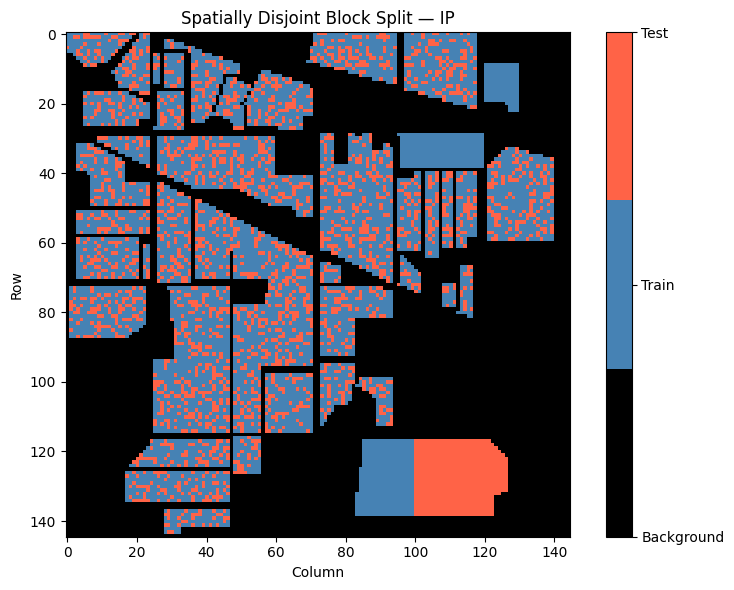

Train pixels: 7,001  |  Test pixels: 3,248
Xtrain: (7001, 25, 25, 15)  ytrain: (7001,)
Xtest:  (3248, 25, 25, 15)   ytest:  (3248,)
Xtrain reshaped: (7001, 25, 25, 15, 1)  ytrain: (7001, 16)
Xtest  reshaped: (3248, 25, 25, 15, 1)   ytest:  (3248, 16)


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# MAIN PIPELINE  (variable names kept identical to original)
# ─────────────────────────────────────────────────────────────────────────────

X, y = loadData(dataset)
X.shape, y.shape

K = X.shape[2]
K = 15
X, pca = applyPCA(X, numComponents=K)
X.shape

# ── Step 1: obtain spatially disjoint masks BEFORE patch extraction
#    (replaces the old call to splitTrainTestSet after createImageCubes)
#train_mask, test_mask = splitTrainTestSet(X, y, test_ratio, randomState=345)

train_mask, test_mask = splitTrainTestSet(X, y, testRatio=0.3, randomState=345)

# Visualise so the reviewer can see the disjoint blocks
visualizeSpatialSplit(train_mask, test_mask,
                      title=f'Spatially Disjoint Block Split — {dataset}')

# ── Step 2: extract patches separately for each spatial partition
Xtrain, ytrain = createImageCubes(X, y, windowSize=windowSize, spatial_mask=train_mask)
Xtest,  ytest  = createImageCubes(X, y, windowSize=windowSize, spatial_mask=test_mask)

print(f"Xtrain: {Xtrain.shape}  ytrain: {ytrain.shape}")
print(f"Xtest:  {Xtest.shape}   ytest:  {ytest.shape}")

# ── Shapes expected by the rest of the pipeline (unchanged) ──────────────────
Xtrain = Xtrain.reshape(-1, windowSize, windowSize, K, 1)
Xtest  = Xtest.reshape(-1,  windowSize, windowSize, K, 1)

num_classes = output_units      # 9 for PU

ytrain = keras.utils.to_categorical(ytrain, num_classes=num_classes)
ytest  = keras.utils.to_categorical(ytest,  num_classes=num_classes)

print(f"Xtrain reshaped: {Xtrain.shape}  ytrain: {ytrain.shape}")
print(f"Xtest  reshaped: {Xtest.shape}   ytest:  {ytest.shape}")


In [ ]:
S = windowSize
L = K
output_units = 9 if (dataset == 'PU' or dataset == 'PC') else 16

In [ ]:
from keras.layers import Reshape
input_shape = (S, S, L, 1)

# Define first branch
input_layer1 = Input(shape=input_shape)
x = Conv3D(filters=16, kernel_size=(3, 3, 3), activation='relu', padding='same')(input_layer1)
x = Conv3D(filters=32, kernel_size=(3, 3, 3), activation='relu', padding='same')(x)
x = Conv3D(filters=64, kernel_size=(3, 3, 3), activation='relu', padding='same')(x)
x = Reshape((S, S, -1))(x)
x = Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same')(x)
encoded1 = Flatten()(x)
encoded1 = Dense(units=256, activation='relu')(encoded1)
encoded1 = Dense(units=6*6*64, activation='relu')(encoded1)
encoded1 = Reshape((6, 6, 64))(encoded1)

# Define second branch
input_layer2 = Input(shape=input_shape[:-1])
y2 = Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same')(input_layer2)
y2 = MaxPooling2D(pool_size=(2, 2))(y2)
y2 = Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same')(y2)
y2 = MaxPooling2D(pool_size=(2, 2))(y2)
y2 = Flatten()(y2)
y2 = Dense(units=6*6*64, activation='relu')(y2)
encoded2 = Reshape((6, 6, 64))(y2)

# Merge two branches and add classification layers
merged_layer = concatenate([encoded1, encoded2])
z = Flatten()(merged_layer)
z = Dense(units=256, activation='relu')(z)
z = Dense(units=128, activation='relu')(z)
output_layer = Dense(units=output_units, activation='softmax')(z)

model = Model(inputs=[input_layer1, input_layer2], outputs=output_layer)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 25, 25,    │          0 │ -                 │
│ (InputLayer)        │ 15, 1)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_3 (Conv3D)   │ (None, 25, 25,    │        448 │ input_layer_2[0]… │
│                     │ 15, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_4 (Conv3D)   │ (None, 25, 25,    │     13,856 │ conv3d_3[0][0]    │
│                     │ 15, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 25, 25,    │          0 │ -                 │
│ (InputLayer)        │ 15)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_5 (Conv3D)   │ (None, 25, 25,    │     55,360 │ conv3d_4[0][0]    │
│                     │ 15, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 25, 25,    │      2,176 │ input_layer_3[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 25, 25,    │          0 │ conv3d_5[0][0]    │
│                     │ 960)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 12, 12,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 25, 25,    │  1,106,048 │ reshape_3[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 12, 12,    │      4,640 │ max_pooling2d_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 80000)     │          0 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 6, 6, 32)  │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │ 20,480,256 │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 1152)      │          0 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 2304)      │    592,128 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 2304)      │  2,656,512 │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 6, 6, 64)  │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, 6, 6, 64)  │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 6, 6, 128) │          0 │ reshape_4[0][0],  │
│ (Concatenate)       │                   │            │ reshape_5[0][0] 

 Total params: 26,126,288 (99.66 MB)

 Trainable params: 26,126,288 (99.66 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compiling the model
adam = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])


In [ ]:
# checkpoint
filepath = "best-model.keras"
checkpoint = ModelCheckpoint(filepath, monitor='acc', verbose=1, save_best_only=True, mode='max')
callbacks_list = [checkpoint]

In [ ]:
import time

train_start_time = time.time()
history = model.fit(x=[Xtrain, Xtrain], y=ytrain, batch_size=36, epochs=100, callbacks=callbacks_list)
train_end_time = time.time()
train_time = train_end_time - train_start_time
print(f'Total training phase took {train_time:.2f} seconds')


Epoch 1/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.5739 - loss: 1.5058

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning:

Can save best model only with acc available.




Epoch 1: finished saving model to best-model.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 33s 142ms/step - accuracy: 0.8017 - loss: 0.6611
Epoch 2/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9803 - loss: 0.0586
Epoch 2: finished saving model to best-model.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 21s 107ms/step - accuracy: 0.9839 - loss: 0.0486
Epoch 3/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9925 - loss: 0.0270
Epoch 3: finished saving model to best-model.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 24s 121ms/step - accuracy: 0.9917 - loss: 0.0310
Epoch 4/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9950 - loss: 0.0140
Epoch 4: finished saving model to best-model.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 22s 115ms/step - accuracy: 0.9944 - loss: 0.0198
Epoch 5/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9890 - loss: 0.0409
Epoch 5: finished saving model to best-model.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 21s 107ms/step - accuracy: 0.9893 - loss: 0.0403
Ep

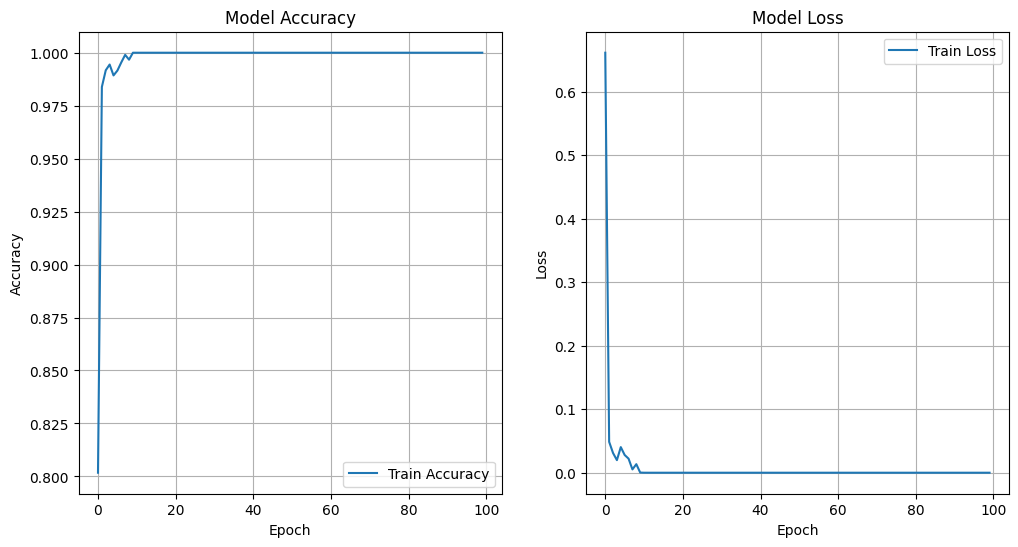

In [ ]:
# Plotting
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(loc='lower right'); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.title('Model Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(loc='upper right'); plt.grid(True)

plt.show()


In [ ]:
model.save("best-model.keras")
model.load_weights("best-model.keras")
model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])


In [ ]:
test_start_time = time.time()
Y_pred_test = model.predict([Xtest, Xtest])
y_pred_test = np.argmax(Y_pred_test, axis=1)
test_end_time = time.time()
test_time = test_end_time - test_start_time

#classification = classification_report(np.argmax(ytest, axis=1), y_pred_test)
classification = classification = classification_report(np.argmax(ytest, axis=1), y_pred_test, zero_division=0)
print(classification)
print(f'Total testing phase took {test_time:.2f} seconds')


102/102 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.99      1.00      1.00       428
           2       1.00      1.00      1.00       249
           3       1.00      1.00      1.00        71
           4       0.99      1.00      0.99       145
           5       1.00      1.00      1.00       219
           6       1.00      1.00      1.00         8
           7       0.99      1.00      1.00       143
           8       1.00      1.00      1.00         6
           9       1.00      1.00      1.00       292
          10       1.00      1.00      1.00       736
          11       1.00      1.00      1.00       178
          12       1.00      1.00      1.00        62
          13       1.00      0.99      0.99       553
          14       1.00      1.00      1.00       116
          15       1.00      1.00      1.00        28

    accuracy                          

In [ ]:
def AA_andEachClassAccuracy(confusion_matrix):
    counter = confusion_matrix.shape[0]
    list_diag = np.diag(confusion_matrix)
    list_raw_sum = np.sum(confusion_matrix, axis=1)
    each_acc = np.nan_to_num(truediv(list_diag, list_raw_sum))
    average_acc = np.mean(each_acc)
    return each_acc, average_acc


In [ ]:
import seaborn as sns

SAVE_PATH = ''

def reports(X_test, y_test, name):
    Y_pred = model.predict([X_test, X_test])
    y_pred = np.argmax(Y_pred, axis=1)

    if name == 'IP':
        target_names = ['Alfalfa', 'Corn-notill', 'Corn-mintill', 'Corn',
                        'Grass-pasture', 'Grass-trees', 'Grass-pasture-mowed',
                        'Hay-windrowed', 'Oats', 'Soybean-notill', 'Soybean-mintill',
                        'Soybean-clean', 'Wheat', 'Woods', 'Buildings-Grass-Trees-Drives',
                        'Stone-Steel-Towers']
    elif name == 'SA':
        target_names = ['Brocoli_green_weeds_1', 'Brocoli_green_weeds_2', 'Fallow',
                        'Fallow_rough_plow', 'Fallow_smooth', 'Stubble', 'Celery',
                        'Grapes_untrained', 'Soil_vinyard_develop', 'Corn_senesced_green_weeds',
                        'Lettuce_romaine_4wk', 'Lettuce_romaine_5wk', 'Lettuce_romaine_6wk',
                        'Lettuce_romaine_7wk', 'Vinyard_untrained', 'Vinyard_vertical_trellis']
    elif name == 'PU':
        target_names = ['Asphalt', 'Meadows', 'Gravel', 'Trees', 'Painted metal sheets',
                        'Bare Soil', 'Bitumen', 'Self-Blocking Bricks', 'Shadows']

    classification = classification_report(np.argmax(y_test, axis=1), y_pred, target_names=target_names)
    oa = accuracy_score(np.argmax(y_test, axis=1), y_pred)
    confusion = confusion_matrix(np.argmax(y_test, axis=1), y_pred)
    each_acc, aa = AA_andEachClassAccuracy(confusion)
    kappa = cohen_kappa_score(np.argmax(y_test, axis=1), y_pred)
    score = model.evaluate([X_test, X_test], y_test, batch_size=32)
    Test_Loss     = score[0] * 100
    Test_accuracy = score[1] * 100

    plt.figure(figsize=(10, 10))
    sns.heatmap(confusion, annot=True, fmt='d',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted Label'); plt.ylabel('True Label')
    plt.savefig(f'confusion_matrix_{name}.png', bbox_inches='tight', dpi=400)
    plt.show()

    return classification, confusion, Test_Loss, Test_accuracy, oa * 100, each_acc * 100, aa * 100, kappa * 100


102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step
102/102 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9982 - loss: 0.0062    


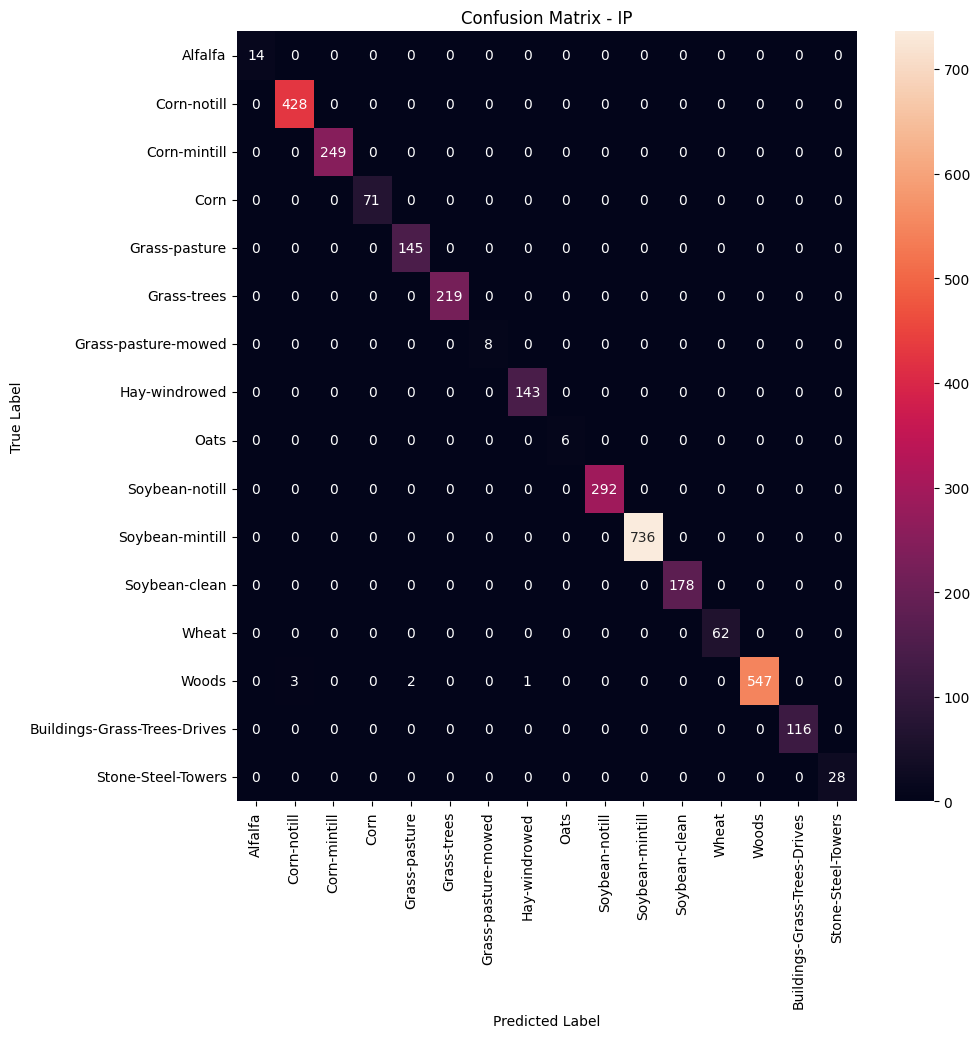

In [ ]:
classification, confusion, Test_loss, Test_accuracy, oa, each_acc, aa, kappa = reports(Xtest, ytest, dataset)
classification = str(classification)
confusion = str(confusion)
file_name = "classification_report_YNet_PU.txt"

with open(file_name, 'w') as x_file:
    x_file.write('{} Test loss (%)'.format(Test_loss))
    x_file.write('\n')
    x_file.write('{} Test accuracy (%)'.format(Test_accuracy))
    x_file.write('\n\n')
    x_file.write('{} Kappa accuracy (%)'.format(kappa))
    x_file.write('\n')
    x_file.write('{} Overall accuracy (%)'.format(oa))
    x_file.write('\n')
    x_file.write('{} Average accuracy (%)'.format(aa))
    x_file.write('\n\n')
    x_file.write('{}'.format(classification))
    x_file.write('\n')
    x_file.write('{}'.format(confusion))